
TASK 4: EMAIL SPAM DETECTION WITH MACHINE LEARNING

AICTE Oasis Infobyte Internship

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [2]:
# HELPER: Create realistic spam/ham dataset
def create_sample_data(n=1000):
    np.random.seed(42)
    spam_templates = [
        "Congratulations! You've won a FREE prize. Click here now to claim your reward!",
        "URGENT: Your account has been compromised. Verify now at this link immediately!",
        "Make $5000 per week working from home. Limited offer — act now! Free sign-up!",
        "You are selected for a special offer. Buy now and get 80% discount TODAY ONLY!",
        "Dear winner, your number has been selected. Send your details to claim $1M prize.",
        "Get cheap Rx meds online without prescription. Best prices guaranteed! Order now.",
        "Hot singles in your area are waiting. Click here for FREE access tonight!",
        "Your PayPal account is suspended. Confirm your identity immediately to restore.",
        "Earn easy cash fast! No experience needed. 100% legitimate. Start today for free!",
        "FINAL NOTICE: You owe money. Pay now to avoid legal action. Call this number.",
    ]
    ham_templates = [
        "Hi, are we still on for the team meeting tomorrow at 10am? Let me know your availability.",
        "Please find the attached quarterly report for your review. Let me know if you have questions.",
        "Thanks for your email. I will get back to you by end of day with the information requested.",
        "Reminder: Your dentist appointment is scheduled for Friday at 2pm. Please confirm.",
        "Happy birthday! Hope you have a wonderful day with your family and friends.",
        "Could you please review and approve the budget proposal I sent last week? Thanks.",
        "The conference call has been rescheduled to 3pm. Please update your calendar accordingly.",
        "I have attached the invoice for the services rendered this month. Due in 30 days.",
        "Your order #12345 has been shipped and will arrive in 3-5 business days. Track here.",
        "Can you send me the updated project timeline when you get a chance? No rush.",
    ]
    records = []
    for i in range(n):
        is_spam = np.random.random() < 0.3
        if is_spam:
            base = np.random.choice(spam_templates)
            noise = np.random.choice(['', ' CLICK NOW!', ' Limited time!', ' Act FAST!', ''])
            records.append({'label': 'spam', 'message': base + noise})
        else:
            base = np.random.choice(ham_templates)
            words = ['Best,', 'Regards,', 'Thanks,', 'Cheers,', '']
            records.append({'label': 'ham', 'message': base + ' ' + np.random.choice(words)})
    return pd.DataFrame(records)


In [3]:
# TEXT CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [4]:
# 1. LOAD DATASET
print("=" * 60)
print("      EMAIL SPAM DETECTION WITH MACHINE LEARNING")
print("=" * 60)

try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
    df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
    print("\n[1] Dataset loaded from spam.csv")
except FileNotFoundError:
    try:
        df = pd.read_csv('mail_data.csv')
        df.columns = df.columns.str.lower().str.strip()
        if 'category' in df.columns:
            df = df.rename(columns={'category': 'label', 'message': 'message'})
        print("\n[1] Dataset loaded from mail_data.csv")
    except FileNotFoundError:
        print("\n[1] CSV not found — using generated sample data.")
        print("    (Place 'spam.csv' in the same folder for real data.)")
        df = create_sample_data()

print(f"    Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

      EMAIL SPAM DETECTION WITH MACHINE LEARNING

[1] CSV not found — using generated sample data.
    (Place 'spam.csv' in the same folder for real data.)
    Shape: (1000, 2)

First 5 rows:
  label                                            message
0   ham  I have attached the invoice for the services r...
1   ham  Can you send me the updated project timeline w...
2  spam  Your PayPal account is suspended. Confirm your...
3   ham  I have attached the invoice for the services r...
4  spam  URGENT: Your account has been compromised. Ver...


In [5]:
# 2. DATA CLEANING & EDA
print("\n[2] Data Cleaning...")
df.dropna(subset=['message', 'label'], inplace=True)
df.drop_duplicates(inplace=True)
df['label'] = df['label'].str.lower().str.strip()
df['label_num'] = (df['label'] == 'spam').astype(int)
df['clean_message'] = df['message'].apply(clean_text)
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(str(x).split()))

print(f"    Cleaned shape: {df.shape}")
print(f"\nClass Distribution:\n{df['label'].value_counts()}")
print(f"    Spam percentage: {df['label_num'].mean()*100:.1f}%")


[2] Data Cleaning...
    Cleaned shape: (90, 6)

Class Distribution:
label
ham     50
spam    40
Name: count, dtype: int64
    Spam percentage: 44.4%



[3] Generating EDA Visualizations...


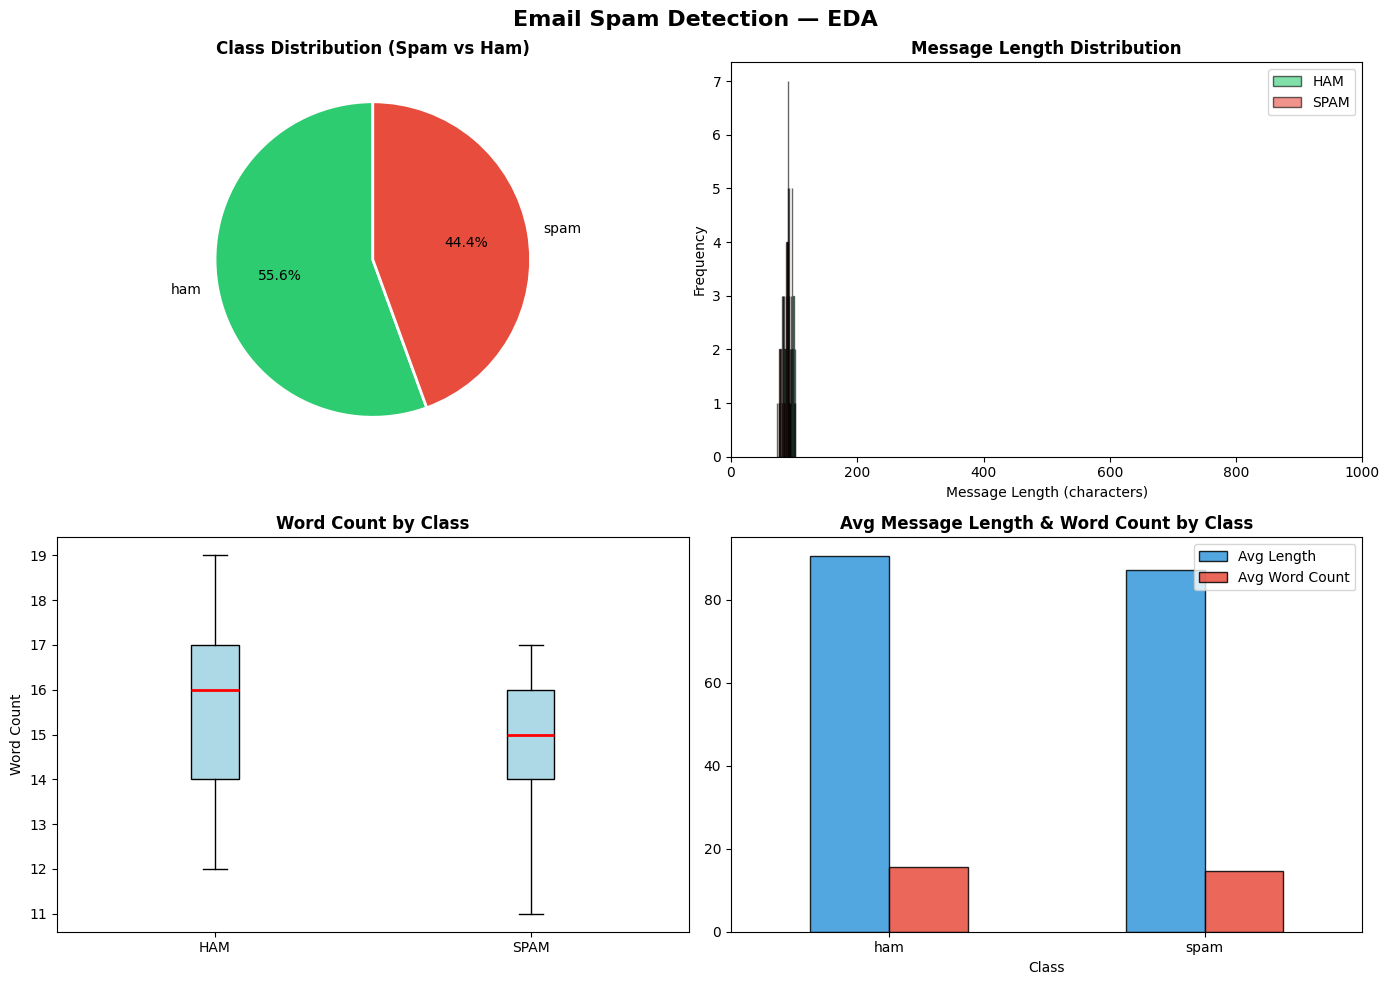

    Saved: spam_eda.png


In [14]:
# 3. EDA VISUALIZATIONS
print("\n[3] Generating EDA Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Email Spam Detection — EDA", fontsize=16, fontweight='bold')

# Class distribution pie
counts = df['label'].value_counts()
axes[0, 0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#e74c3c'], startangle=90,
               wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0, 0].set_title('Class Distribution (Spam vs Ham)', fontweight='bold')

# Message length distribution
for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    subset = df[df['label'] == label]['message_length']
    axes[0, 1].hist(subset, bins=40, alpha=0.6, color=color, label=label.upper(), edgecolor='black')
axes[0, 1].set_title('Message Length Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Message Length (characters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 1000)

# Word count by class
spam_wc = df[df['label'] == 'spam']['word_count']
ham_wc = df[df['label'] == 'ham']['word_count']
axes[1, 0].boxplot([ham_wc, spam_wc], labels=['HAM', 'SPAM'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Word Count by Class', fontweight='bold')
axes[1, 0].set_ylabel('Word Count')

# Average stats comparison
stats_df = df.groupby('label')[['message_length', 'word_count']].mean()
stats_df.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Avg Message Length & Word Count by Class', fontweight='bold')
axes[1, 1].set_xlabel('Class')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(['Avg Length', 'Avg Word Count'])

plt.tight_layout()
plt.savefig('spam_eda.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("    Saved: spam_eda.png")

In [7]:
# 4. PREPARE FEATURES
print("\n[4] Preparing Text Features (TF-IDF)...")

X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"    Train: {len(X_train)} | Test: {len(X_test)}")


[4] Preparing Text Features (TF-IDF)...
    Train: 72 | Test: 18


In [8]:
# 5. MODEL TRAINING & COMPARISON
print("\n[5] Training Multiple Models...")
print("-" * 55)

models = {
    'Multinomial Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('model', MultinomialNB())
    ]),
    'Bernoulli Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, binary=True)),
        ('model', BernoulliNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('model', LinearSVC(random_state=42, max_iter=2000))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000)),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    results[name] = {'pipeline': pipe, 'y_pred': y_pred, 'accuracy': acc,
                     'precision': prec, 'recall': rec, 'f1': f1}
    print(f"    {name:<25} | Acc:{acc:.4f} | P:{prec:.4f} | R:{rec:.4f} | F1:{f1:.4f}")



[5] Training Multiple Models...
-------------------------------------------------------
    Multinomial Naive Bayes   | Acc:1.0000 | P:1.0000 | R:1.0000 | F1:1.0000
    Bernoulli Naive Bayes     | Acc:1.0000 | P:1.0000 | R:1.0000 | F1:1.0000
    Logistic Regression       | Acc:1.0000 | P:1.0000 | R:1.0000 | F1:1.0000
    Linear SVM                | Acc:1.0000 | P:1.0000 | R:1.0000 | F1:1.0000
    Random Forest             | Acc:1.0000 | P:1.0000 | R:1.0000 | F1:1.0000


In [9]:
# 6. BEST MODEL
best_name = max(results, key=lambda k: results[k]['f1'])
best = results[best_name]
print(f"\n[6] Best Model: {best_name} (F1: {best['f1']:.4f})")
print("\nClassification Report:")
print(classification_report(y_test, best['y_pred'], target_names=['Ham', 'Spam']))


[6] Best Model: Multinomial Naive Bayes (F1: 1.0000)

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00        10
        Spam       1.00      1.00      1.00         8

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



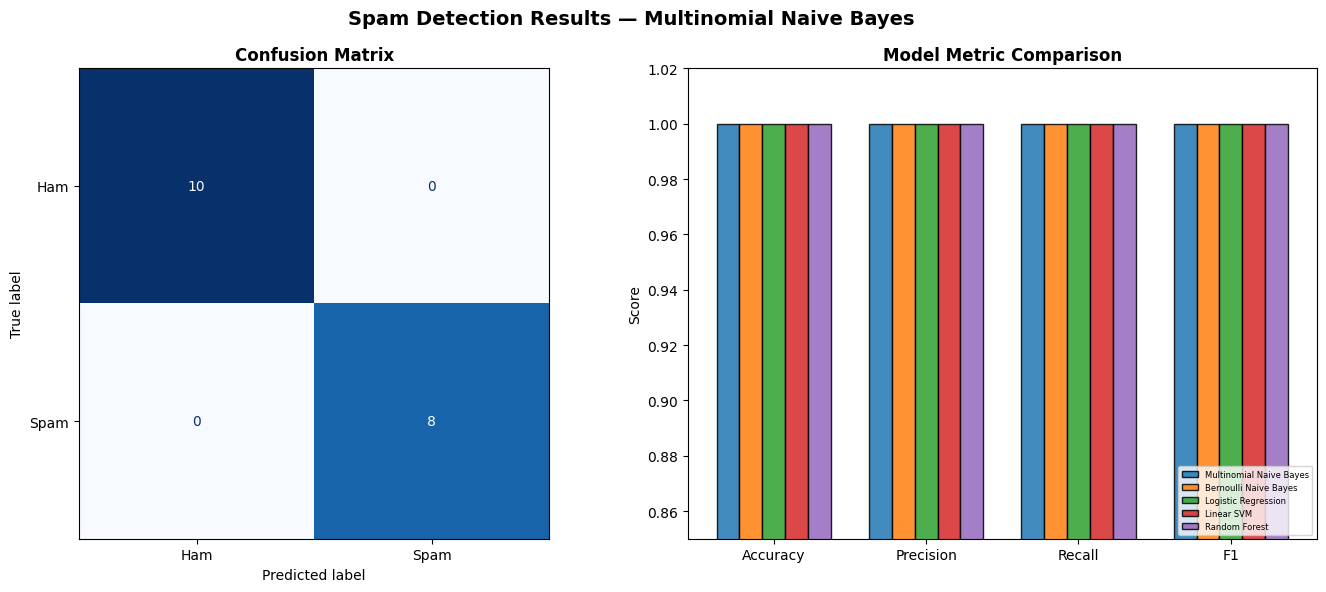

    Saved: spam_model_results.png


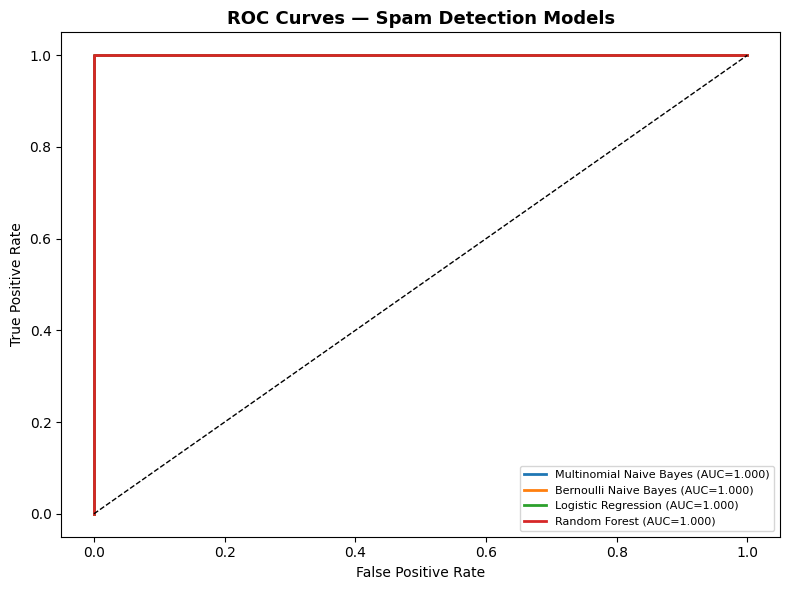

    Saved: spam_roc_curve.png


In [15]:
# 7. VISUALIZATIONS — RESULTS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Spam Detection Results — {best_name}", fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Metric comparison bar chart
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.15
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    axes[1].bar(x + i * width, vals, width, label=name, alpha=0.85, edgecolor='black')
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'], fontsize=10)
axes[1].set_ylim(0.85, 1.02)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Metric Comparison', fontweight='bold')
axes[1].legend(fontsize=6, loc='lower right')

plt.tight_layout()
plt.savefig('spam_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("    Saved: spam_model_results.png")

# ROC Curve (models with predict_proba)
plt.figure(figsize=(8, 6))
roc_models = {k: v for k, v in results.items() if k not in ['Linear SVM']}
for name, res in roc_models.items():
    pipe = res['pipeline']
    if hasattr(pipe.named_steps['model'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Spam Detection Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('spam_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("    Saved: spam_roc_curve.png")


[7] Top Spam/Ham Indicator Words (Logistic Regression):
    Top SPAM words: ['now', 'click', 'limited', 'free', 'time', 'limited time', 'fast', 'act', 'immediately', 'account', 'click now', 'selected', 'today', 'number', 'offer']
    Top HAM  words: ['the', 'please', 'thanks', 'have', 'me', 'you', 'pm please', 'num pm', 'pm', 'review', 'you have', 'at num', 'cheers', 'with', 'day with']


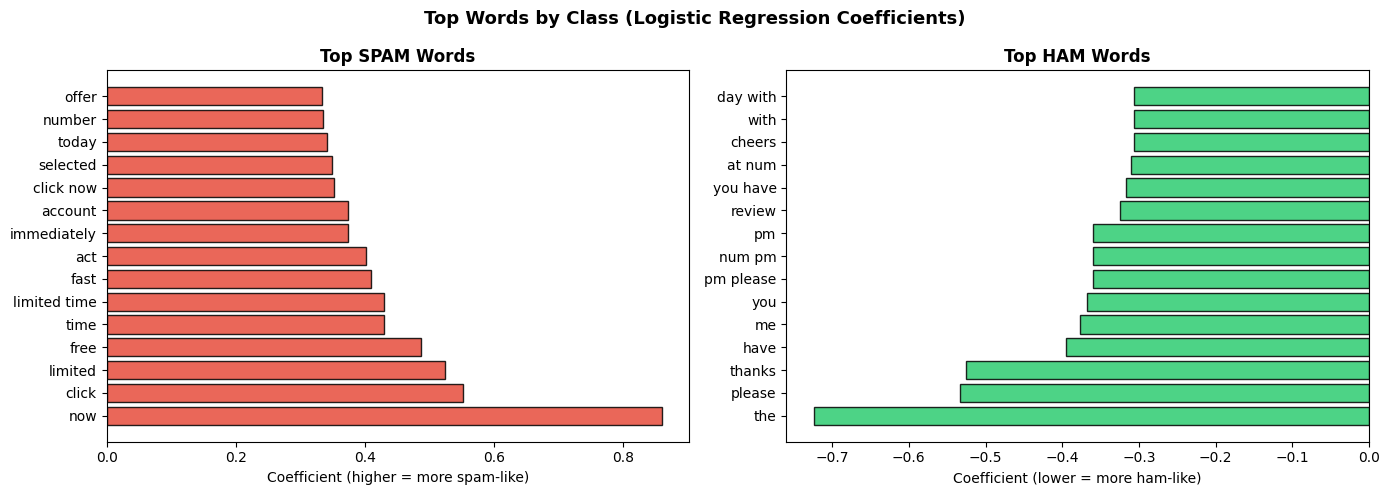

    Saved: spam_top_words.png


In [16]:
# 8. TOP SPAM INDICATOR WORDS (Logistic Regression)
print("\n[7] Top Spam/Ham Indicator Words (Logistic Regression):")
lr_pipe = results['Logistic Regression']['pipeline']
feature_names = lr_pipe.named_steps['tfidf'].get_feature_names_out()
coefs = lr_pipe.named_steps['model'].coef_[0]

top_spam = np.argsort(coefs)[-15:][::-1]
top_ham = np.argsort(coefs)[:15]

print("    Top SPAM words:", [feature_names[i] for i in top_spam])
print("    Top HAM  words:", [feature_names[i] for i in top_ham])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top Words by Class (Logistic Regression Coefficients)', fontsize=13, fontweight='bold')
axes[0].barh(range(15), coefs[top_spam], color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([feature_names[i] for i in top_spam])
axes[0].set_title('Top SPAM Words', fontweight='bold')
axes[0].set_xlabel('Coefficient (higher = more spam-like)')
axes[1].barh(range(15), coefs[top_ham], color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([feature_names[i] for i in top_ham])
axes[1].set_title('Top HAM Words', fontweight='bold')
axes[1].set_xlabel('Coefficient (lower = more ham-like)')
plt.tight_layout()
plt.savefig('spam_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("    Saved: spam_top_words.png")

In [17]:
# 9. DEMO PREDICTIONS
print("\n[8] Demo Predictions:")
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim NOW!!",
    "Hi, are we still meeting for lunch at 1pm tomorrow? Let me know!",
    "URGENT: Your bank account is suspended. Verify your identity immediately.",
    "Please review the attached project report and share your feedback.",
    "Get rich quick! Make $5000/week from home. No experience needed. Free signup!",
]
best_pipe = best['pipeline']
for msg in test_messages:
    cleaned = clean_text(msg)
    pred = best_pipe.predict([cleaned])[0]
    label = "🔴 SPAM" if pred == 1 else "✅ HAM"
    print(f"    {label} | {msg[:60]}...")

print("\n" + "=" * 60)
print("  EMAIL SPAM DETECTION COMPLETE!")
print("=" * 60)


[8] Demo Predictions:
    🔴 SPAM | Congratulations! You've won a FREE iPhone. Click here to cla...
    ✅ HAM | Hi, are we still meeting for lunch at 1pm tomorrow? Let me k...
    🔴 SPAM | URGENT: Your bank account is suspended. Verify your identity...
    ✅ HAM | Please review the attached project report and share your fee...
    🔴 SPAM | Get rich quick! Make $5000/week from home. No experience nee...

  EMAIL SPAM DETECTION COMPLETE!
